In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
data=pd.read_csv("housing.csv")

In [4]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [5]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
data.dropna(inplace=True)

In [7]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [8]:
from sklearn.model_selection import train_test_split
X=data.drop(['median_house_value'],axis=1)
y=data['median_house_value']

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)


In [10]:
train_data=X_train.join(y_train)

In [11]:
train_data=X_train.join(y_train)

In [12]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
15827,-122.42,37.75,52.0,1564.0,396.0,1162.0,374.0,3.0000,NEAR BAY,275000.0
2105,-119.76,36.75,39.0,2233.0,563.0,2031.0,491.0,1.8641,INLAND,50800.0
12734,-121.34,38.58,18.0,1631.0,228.0,599.0,228.0,7.8031,INLAND,267200.0
12403,-116.25,33.69,5.0,1664.0,444.0,907.0,374.0,2.7667,INLAND,92900.0
89,-122.27,37.80,52.0,249.0,78.0,396.0,85.0,1.2434,NEAR BAY,500001.0
...,...,...,...,...,...,...,...,...,...,...
9440,-120.31,37.64,11.0,2403.0,497.0,890.0,344.0,3.0000,INLAND,120800.0
1629,-122.16,37.89,32.0,1779.0,241.0,721.0,258.0,8.7589,NEAR BAY,434500.0
7177,-118.18,34.05,41.0,762.0,147.0,817.0,176.0,3.7500,<1H OCEAN,123100.0
17684,-121.85,37.28,17.0,4208.0,954.0,1476.0,904.0,2.3971,<1H OCEAN,87500.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

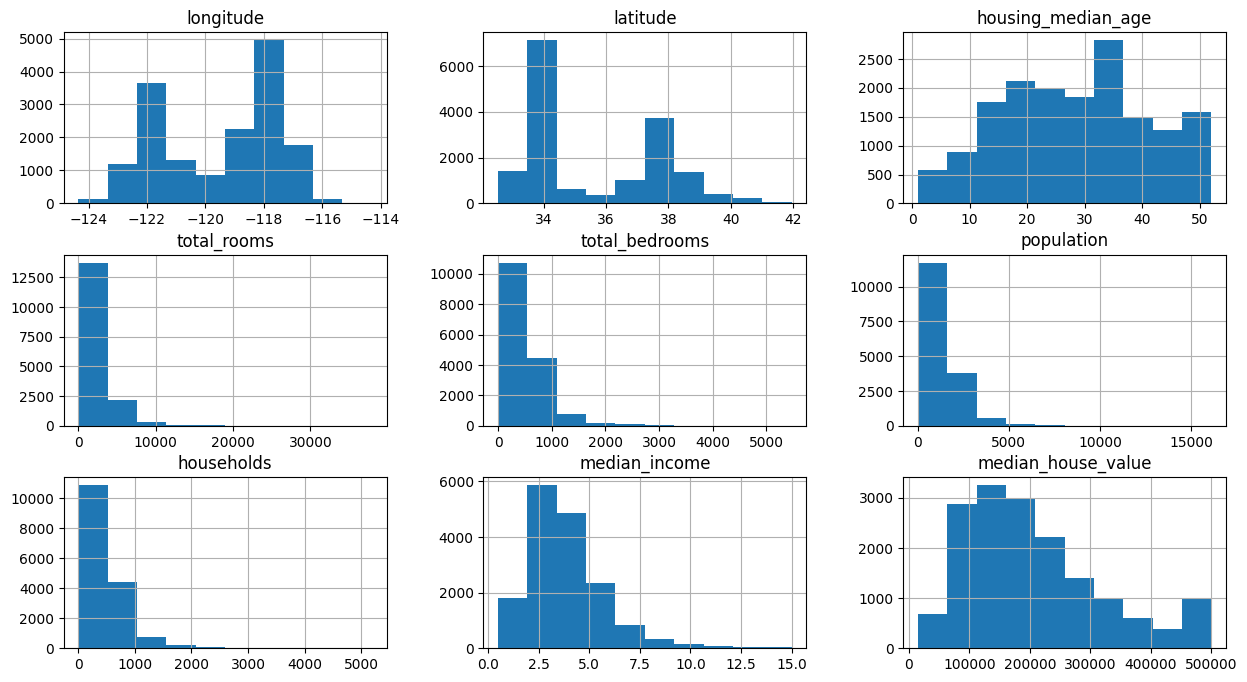

In [13]:
train_data.hist(figsize=(15,8))


<Axes: >

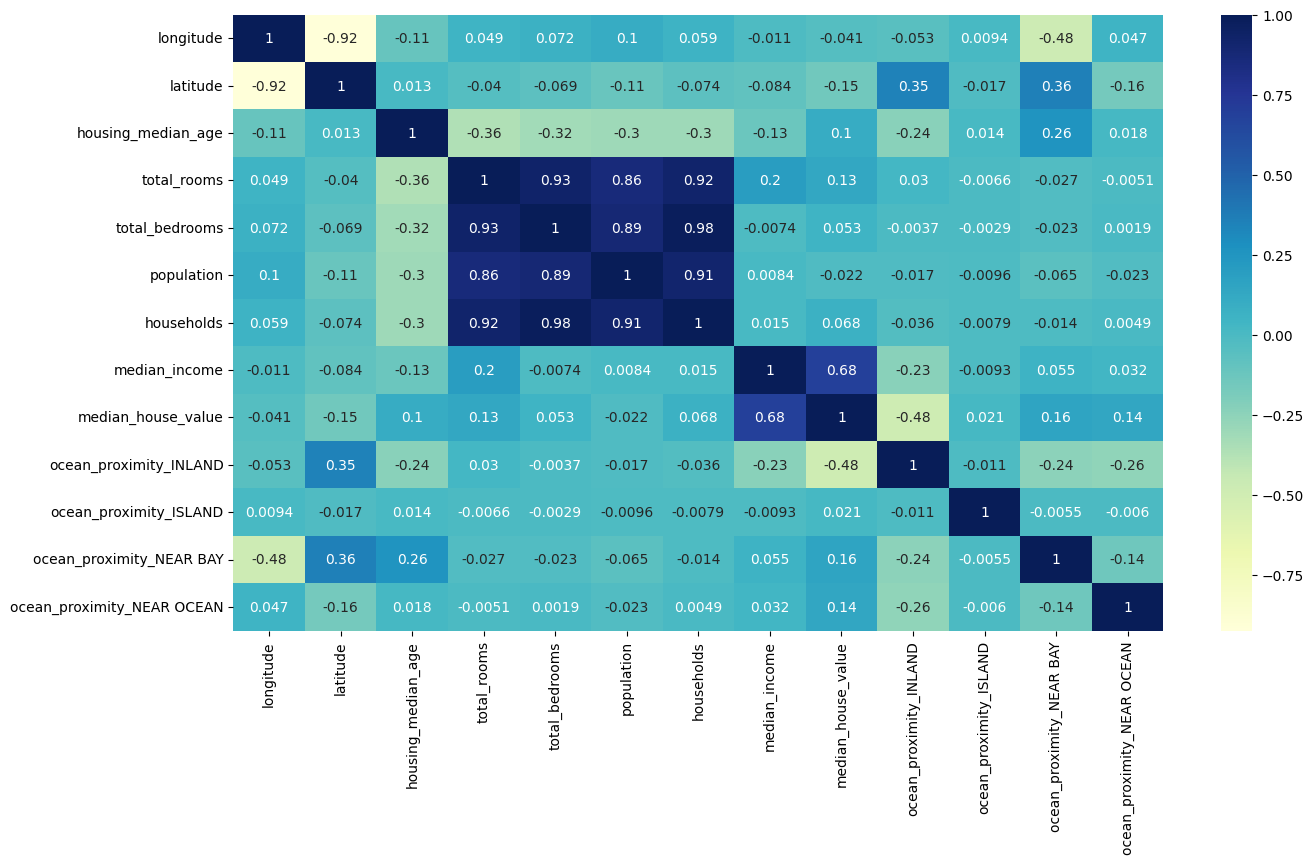

In [14]:
plt.figure(figsize=(15,8))
train_data_encoded = pd.get_dummies(train_data, drop_first=True)
sns.heatmap(train_data_encoded.corr(), annot=True, cmap="YlGnBu")


In [15]:
train_data['total_rooms']=np.log(train_data['total_rooms']+1)
train_data['total_bedrooms']=np.log(train_data['total_bedrooms']+1)
train_data['population']=np.log(train_data['population']+1)
train_data['households']=np.log(train_data['households']+1)



array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

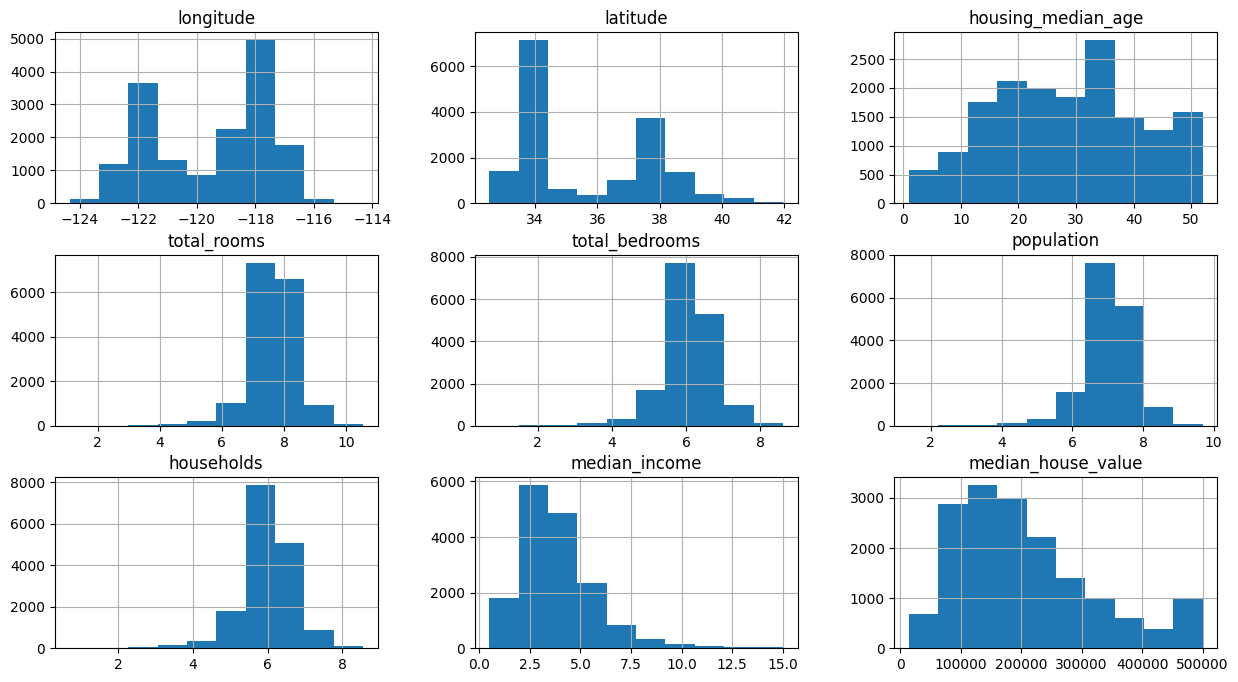

In [16]:
train_data.hist(figsize=(15,8))

In [17]:
train_data=train_data.join(pd.get_dummies(train_data.ocean_proximity )).drop(['ocean_proximity'],axis=1)

In [18]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
15827,-122.42,37.75,52.0,7.355641,5.983936,7.058758,5.926926,3.0000,275000.0,False,False,False,True,False
2105,-119.76,36.75,39.0,7.711549,6.335054,7.616776,6.198479,1.8641,50800.0,False,True,False,False,False
12734,-121.34,38.58,18.0,7.397562,5.433722,6.396930,5.433722,7.8031,267200.0,False,True,False,False,False
12403,-116.25,33.69,5.0,7.417580,6.098074,6.811244,5.926926,2.7667,92900.0,False,True,False,False,False
89,-122.27,37.80,52.0,5.521461,4.369448,5.983936,4.454347,1.2434,500001.0,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9440,-120.31,37.64,11.0,7.784889,6.210600,6.792344,5.843544,3.0000,120800.0,False,True,False,False,False
1629,-122.16,37.89,32.0,7.484369,5.488938,6.582025,5.556828,8.7589,434500.0,False,False,False,True,False
7177,-118.18,34.05,41.0,6.637258,4.997212,6.706862,5.176150,3.7500,123100.0,True,False,False,False,False
17684,-121.85,37.28,17.0,8.344980,6.861711,7.297768,6.807935,2.3971,87500.0,True,False,False,False,False


<Axes: >

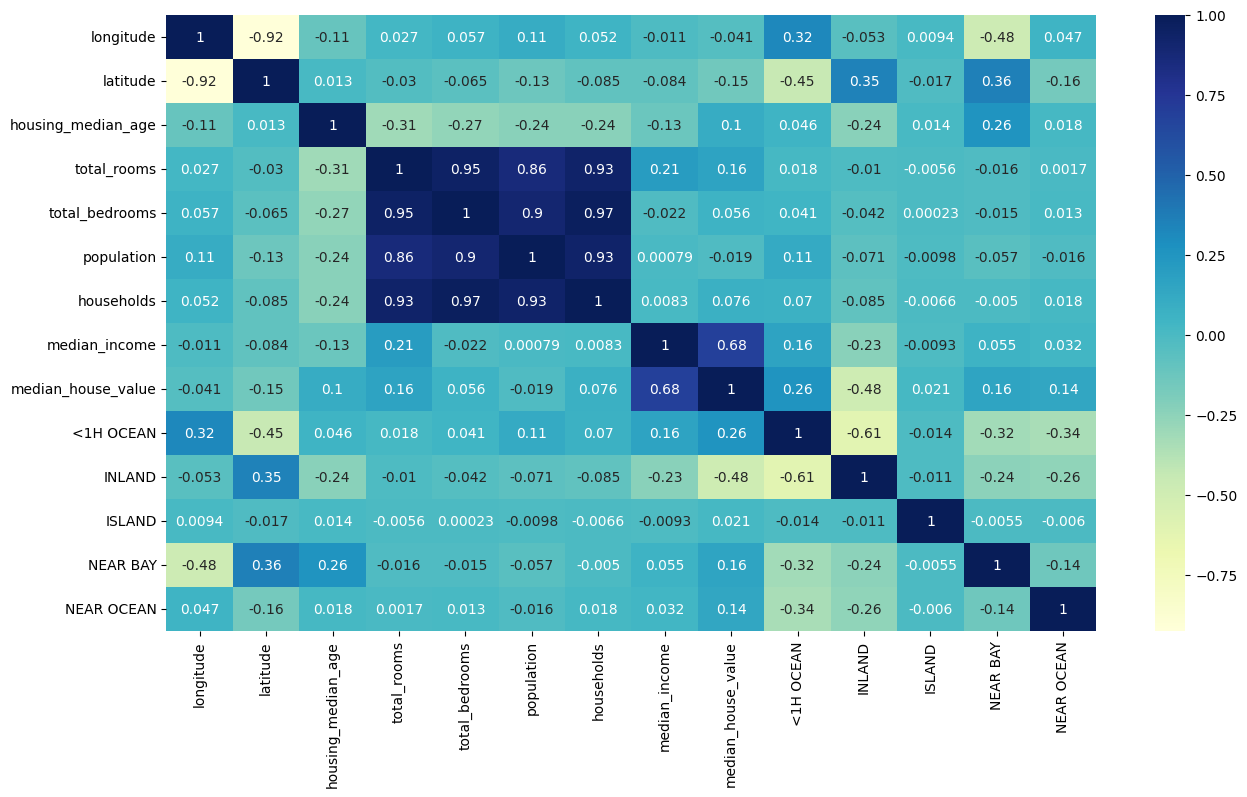

In [19]:
plt.figure(figsize=(15,8))
train_data_encoded = pd.get_dummies(train_data, drop_first=True)
sns.heatmap(train_data_encoded.corr(), annot=True, cmap="YlGnBu")

<Axes: xlabel='latitude', ylabel='longitude'>

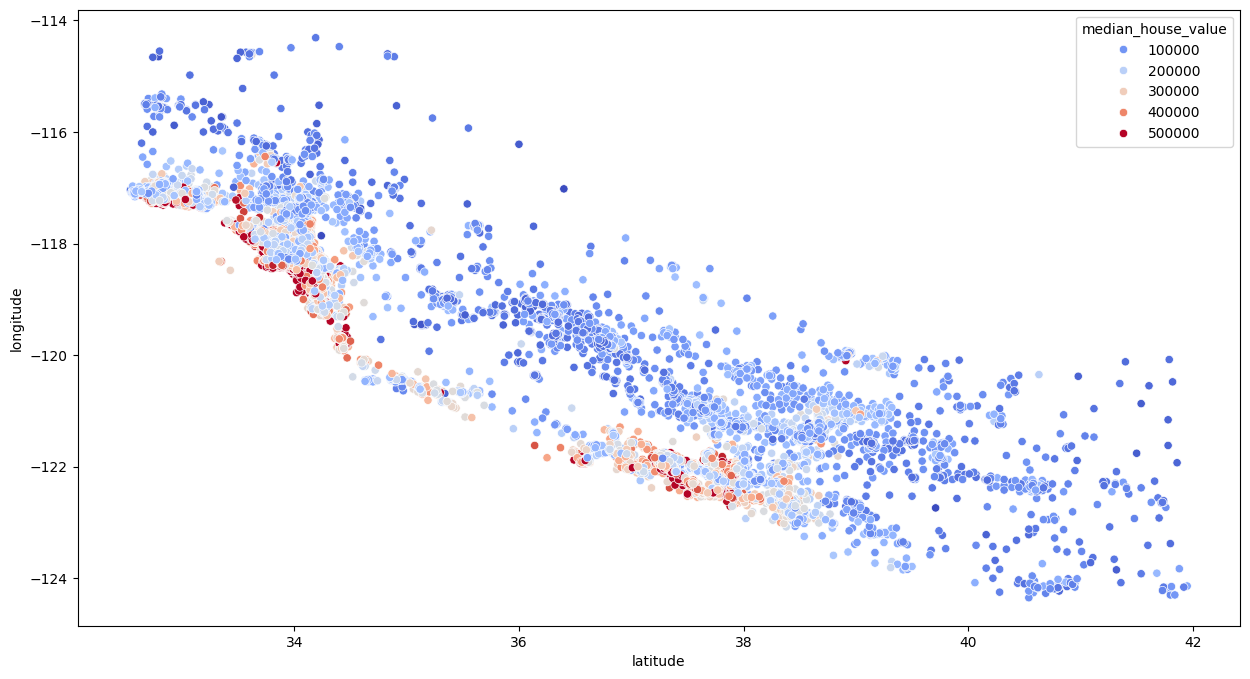

In [20]:
plt.figure(figsize=(15,8))
sns.scatterplot(x="latitude",y="longitude",data=train_data,hue="median_house_value",palette="coolwarm")

In [21]:
train_data['bedroom_ratio']=train_data['total_bedrooms'] / train_data['total_rooms']
train_data['household_rooms']=train_data['total_rooms'] / train_data['households']

<Axes: >

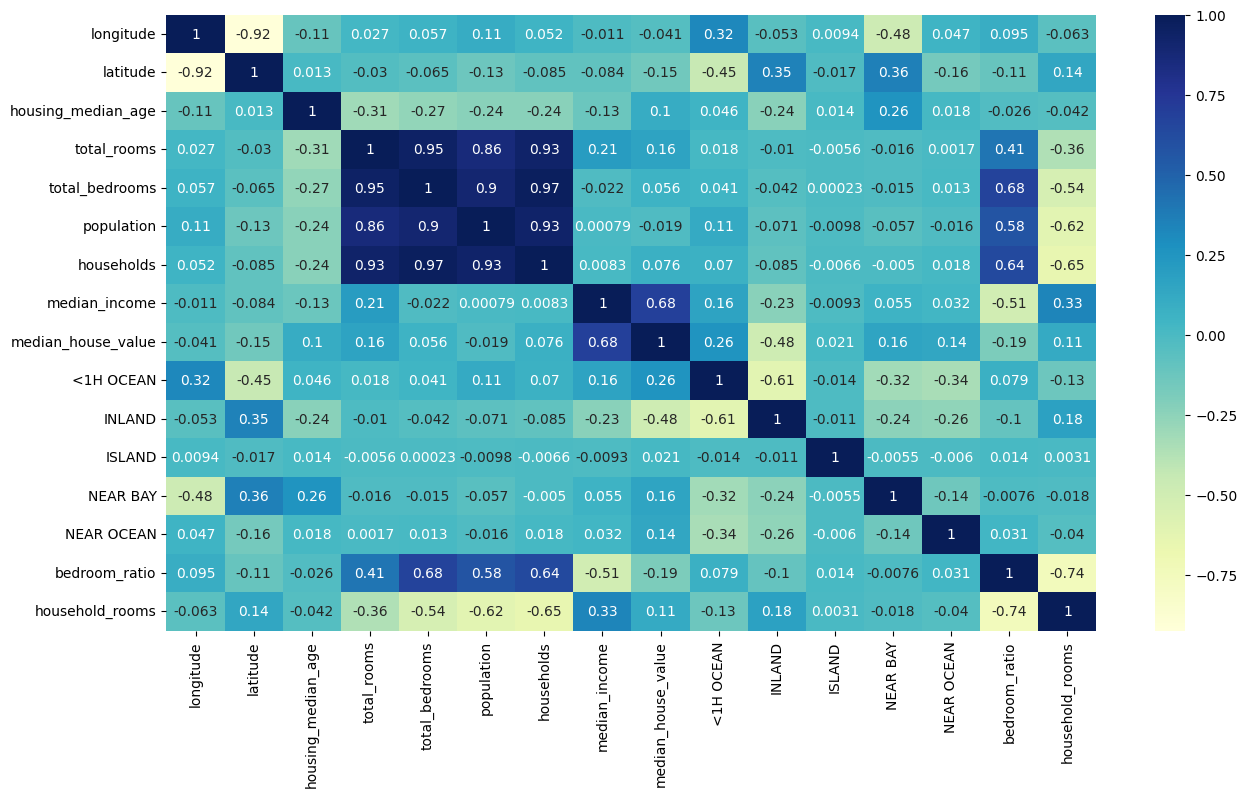

In [22]:
plt.figure(figsize=(15,8))
train_data_encoded = pd.get_dummies(train_data, drop_first=True)
sns.heatmap(train_data_encoded.corr(), annot=True, cmap="YlGnBu")

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
X_train, y_train=train_data.drop(['median_house_value'],axis=1),train_data['median_house_value']
scaler=StandardScaler()
X_train_s=scaler.fit_transform(X_train)
reg= LinearRegression()
reg.fit(X_train_s,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
test_data=X_test.join(y_test)

test_data['total_rooms']=np.log(test_data['total_rooms']+1)
test_data['total_bedrooms']=np.log(test_data['total_bedrooms']+1)
test_data['population']=np.log(test_data['population']+1)
test_data['households']=np.log(test_data['households']+1)

test_data=test_data.join(pd.get_dummies(test_data.ocean_proximity )).drop(['ocean_proximity'],axis=1)

test_data['bedroom_ratio']=test_data['total_bedrooms'] / test_data['total_rooms']
test_data['household_rooms']=test_data['total_rooms'] / test_data['households']



In [25]:
X_test, y_test=test_data.drop(['median_house_value'],axis=1),test_data['median_house_value']

In [26]:
x_test,y_test=test_data.drop(['median_house_value'],axis=1),test_data['median_house_value']

In [27]:
X_test_s=scaler.transform(X_test)

In [28]:
reg.score(X_test_s,y_test)

0.6763837209534936

In [29]:
from sklearn.ensemble import RandomForestRegressor

forest= RandomForestRegressor()
forest.fit(X_train_s,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
forest.score(X_test_s,y_test)

0.8187950115709726

In [31]:
from sklearn.model_selection import GridSearchCV 
forest=RandomForestRegressor()
param_grid={
    "n_estimators":[100,200,300],
    "min_samples_split":[2,4],
    "max_depth":[None,4,8]
    
  }
grid_search=GridSearchCV(forest,param_grid,cv=5,
                         scoring="neg_mean_squared_error",
                         return_train_score=True)
grid_search.fit(X_train_s,y_train)

,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [None, 4, ...], 'min_samples_split': [2, 4], 'n_estimators': [100, 200, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,300


In [32]:
grid_search.best_estimator_

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
grid_search.best_estimator_.score(X_test_s,y_test)

0.8210740486207766